# Notebook 08 — Week 2 Evaluation Report

This is not a training notebook. It is a scientific report — a structured analysis of what we built, loaded entirely from saved artifacts. Every number here is reproducible by re-running this notebook without touching any other notebook.

**Narrative thread:** EDA findings → preprocessing decisions → feature quality → model results → root cause analysis 

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
FIGURES_DIR   = '../reports/figures/'
REPORTS_DIR   = '../reports/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

---
## Section 1 — Data Journey: What We Started With and What We Trained On

Before reading any accuracy number, a reader needs to know what the model actually saw. This section traces every data transformation from raw download to training matrix, showing exactly how many rows survived each step and why each reduction happened.

Data pipeline row counts
  Raw download          : 8,469
  After cleaning (nb03) : 8,077  (-392 nulls / duplicates / boilerplate)
  After preprocessing   : 8,077  (no rows dropped — only text transformed)
  Training set (80%)    : 6,461
  Test set     (20%)    : 1,616


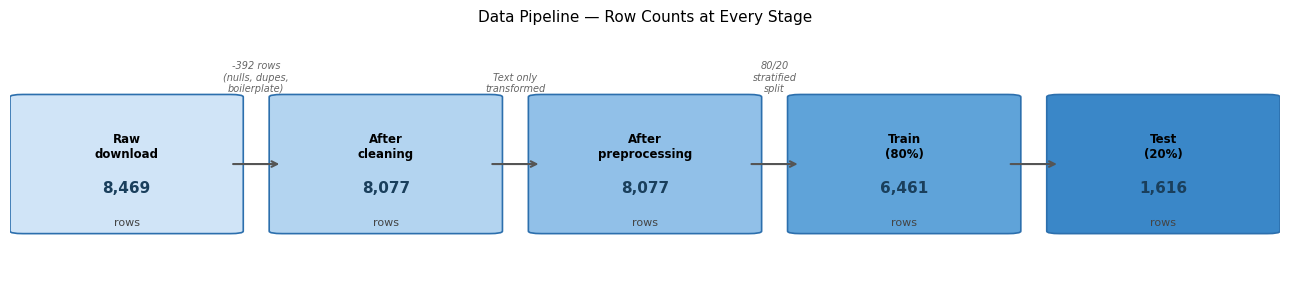

Saved: data_pipeline.png


In [2]:
# load processed data to confirm counts
df = pd.read_csv(PROCESSED_DIR + 'preprocessed_tasks.csv')
y_train_type = pd.read_csv(PROCESSED_DIR + 'y_train_type.csv', index_col=0).squeeze()
y_test_type  = pd.read_csv(PROCESSED_DIR + 'y_test_type.csv',  index_col=0).squeeze()

N_RAW       = 8469
N_CLEANED   = 8077
N_PREPROC   = len(df)
N_TRAIN     = len(y_train_type)
N_TEST      = len(y_test_type)

assert N_PREPROC == N_CLEANED, f'Unexpected preprocessed row count: {N_PREPROC}'
assert N_TRAIN + N_TEST == N_CLEANED

print('Data pipeline row counts')
print(f'  Raw download          : {N_RAW:,}')
print(f'  After cleaning (nb03) : {N_CLEANED:,}  (-{N_RAW - N_CLEANED} nulls / duplicates / boilerplate)')
print(f'  After preprocessing   : {N_PREPROC:,}  (no rows dropped — only text transformed)')
print(f'  Training set (80%)    : {N_TRAIN:,}')
print(f'  Test set     (20%)    : {N_TEST:,}')

# ---- pipeline flow chart ----
stages = [
    ('Raw\ndownload',       N_RAW,     '#d0e4f7'),
    ('After\ncleaning',     N_CLEANED, '#b3d4f0'),
    ('After\npreprocessing',N_PREPROC, '#91c0e8'),
    ('Train\n(80%)',        N_TRAIN,   '#5fa3d9'),
    ('Test\n(20%)',         N_TEST,    '#3a87c8'),
]
labels   = [s[0] for s in stages]
counts   = [s[1] for s in stages]
colors   = [s[2] for s in stages]
reasons  = ['', '-392 rows\n(nulls, dupes,\nboilerplate)', 'Text only\ntransformed', '80/20\nstratified\nsplit', '']

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')
box_w, box_h, gap = 0.16, 0.55, 0.04
positions = [i * (box_w + gap) for i in range(len(stages))]

for i, (lbl, cnt, col) in enumerate(stages):
    x = positions[i]
    rect = mpatches.FancyBboxPatch((x, 0.2), box_w, box_h,
                                    boxstyle='round,pad=0.01', fc=col, ec='#2c6fad', lw=1.2)
    ax.add_patch(rect)
    ax.text(x + box_w/2, 0.2 + box_h/2 + 0.07, lbl,
            ha='center', va='center', fontsize=8.5, fontweight='bold')
    ax.text(x + box_w/2, 0.2 + box_h/2 - 0.10, f'{cnt:,}',
            ha='center', va='center', fontsize=11, fontweight='bold', color='#1a3f5c')
    ax.text(x + box_w/2, 0.2 + box_h/2 - 0.24, 'rows',
            ha='center', va='center', fontsize=8, color='#444')
    if i < len(stages) - 1:
        ax.annotate('', xy=(positions[i+1], 0.475), xytext=(x + box_w, 0.475),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
        if reasons[i+1]:
            ax.text(x + box_w + gap/2, 0.76, reasons[i+1],
                    ha='center', va='bottom', fontsize=7, color='#666', style='italic')

ax.set_xlim(-0.01, positions[-1] + box_w + 0.01)
ax.set_ylim(0, 1)
ax.set_title('Data Pipeline — Row Counts at Every Stage', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'data_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_pipeline.png')

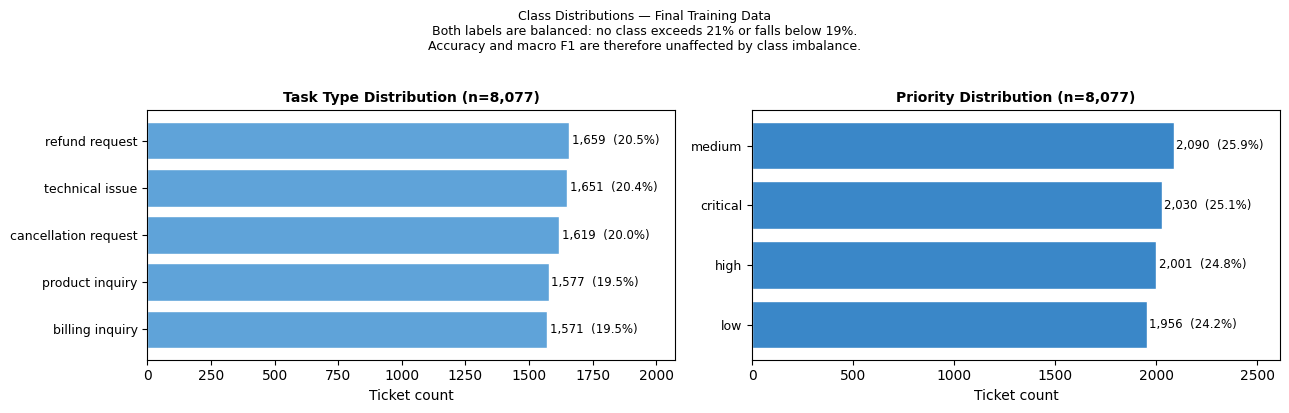

Saved: final_class_distributions.png

Balance check:
  task_type  min share: 19.5%   max share: 20.5%   range: 1.1pp
  priority   min share: 24.2%   max share: 25.9%   range: 1.7pp


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# task type
type_counts = df['task_type'].value_counts().sort_values()
axes[0].barh(type_counts.index, type_counts.values, color='#5fa3d9', edgecolor='white')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 10, i, f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=8.5)
axes[0].set_title('Task Type Distribution (n=8,077)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Ticket count')
axes[0].set_xlim(0, max(type_counts.values) * 1.25)
axes[0].tick_params(axis='y', labelsize=9)

# priority
pri_counts = df['priority'].value_counts().sort_values()
axes[1].barh(pri_counts.index, pri_counts.values, color='#3a87c8', edgecolor='white')
for i, v in enumerate(pri_counts.values):
    axes[1].text(v + 10, i, f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=8.5)
axes[1].set_title('Priority Distribution (n=8,077)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Ticket count')
axes[1].set_xlim(0, max(pri_counts.values) * 1.25)
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('Class Distributions — Final Training Data\n'
             'Both labels are balanced: no class exceeds 21% or falls below 19%.\n'
             'Accuracy and macro F1 are therefore unaffected by class imbalance.',
             fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'final_class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_class_distributions.png')

print('\nBalance check:')
print(f'  task_type  min share: {type_counts.min()/len(df)*100:.1f}%   '
      f'max share: {type_counts.max()/len(df)*100:.1f}%   '
      f'range: {(type_counts.max()-type_counts.min())/len(df)*100:.1f}pp')
print(f'  priority   min share: {pri_counts.min()/len(df)*100:.1f}%   '
      f'max share: {pri_counts.max()/len(df)*100:.1f}%   '
      f'range: {(pri_counts.max()-pri_counts.min())/len(df)*100:.1f}pp')

---
## Section 2 — Feature Quality Assessment

**The question this answers:** Before looking at model accuracy, what quality did our features actually have?

This section exists because our results cannot be understood without understanding the features first. A reader who jumps straight to accuracy numbers will be confused by near-baseline performance. Understanding the features explains it.

### TF-IDF vocabulary — what survived filtering

| Parameter | Value | Effect |
|---|---|---|
| `ngram_range` | `(1, 2)` | Unigrams + bigrams — captures multi-word phrases |
| `min_df` | `10` | Kept terms appearing in ≥ 10 training documents — removed rare noise |
| `max_df` | `0.85` | Removed corpus-wide terms that appear in > 85% of tickets |
| `stop_words` | `['im', 'ive']` | Explicitly removed contraction artifacts and all broken bigrams they formed |
| `sublinear_tf` | `True` | Dampened term frequency to prevent repeated words dominating short tickets |

The filtering chain reduced the raw vocabulary of ~5,577 unique tokens to the final feature matrix. Every reduction was deliberate — each filter was added in response to a specific artifact discovered in the data.

In [4]:
vectorizer   = joblib.load(MODELS_DIR + 'tfidf_vectorizer.pkl')
feature_names = vectorizer.get_feature_names_out()
idf_scores   = vectorizer.idf_
vocab_size   = len(feature_names)

print(f'Final vocabulary size : {vocab_size:,} features')
print(f'  (reduced from ~5,577 raw unique tokens through min_df, max_df, and stop_words filtering)')

# artifact tokens must be absent
print('\n=== ARTIFACT TOKEN CHECK ===')
for token in ['im', 'ive', 'assist']:
    status = 'PRESENT (problem)' if token in vectorizer.vocabulary_ else 'absent (correct)'
    print(f'  {token!r:12s}: {status}')

# broken bigrams must be absent
broken_bigrams = ['device im', 'day im', 'add im', 'refund im', 'error ive', 'ive see']
print('\n=== BROKEN BIGRAM CHECK ===')
for bg in broken_bigrams:
    status = 'PRESENT (problem)' if bg in vectorizer.vocabulary_ else 'absent (correct)'
    print(f'  {bg!r:20s}: {status}')

# IDF distribution
idf_series = pd.Series(idf_scores, index=feature_names).sort_values()
print('\n=== TOP 15 LOWEST-IDF TERMS (appear in most documents) ===')
print(idf_series.head(15).to_string())
print('\n=== TOP 15 HIGHEST-IDF TERMS (rarest terms kept after filtering) ===')
print(idf_series.tail(15).to_string())

Final vocabulary size : 1,306 features
  (reduced from ~5,577 raw unique tokens through min_df, max_df, and stop_words filtering)

=== ARTIFACT TOKEN CHECK ===
  'im'        : absent (correct)
  'ive'       : absent (correct)
  'assist'    : absent (correct)

=== BROKEN BIGRAM CHECK ===
  'device im'         : absent (correct)
  'day im'            : absent (correct)
  'add im'            : absent (correct)
  'refund im'         : absent (correct)
  'error ive'         : absent (correct)
  'ive see'           : absent (correct)

=== TOP 15 LOWEST-IDF TERMS (appear in most documents) ===
product     1.988805
software    2.461141
update      2.543131
data        2.565834
work        2.694510
device      2.709790
step        2.798280
use         2.832504
account     2.914079
time        2.962450
try         2.963552
resolve     2.969080
make        2.973524
network     3.039102
notice      3.055889

=== TOP 15 HIGHEST-IDF TERMS (rarest terms kept after filtering) ===
describe            7

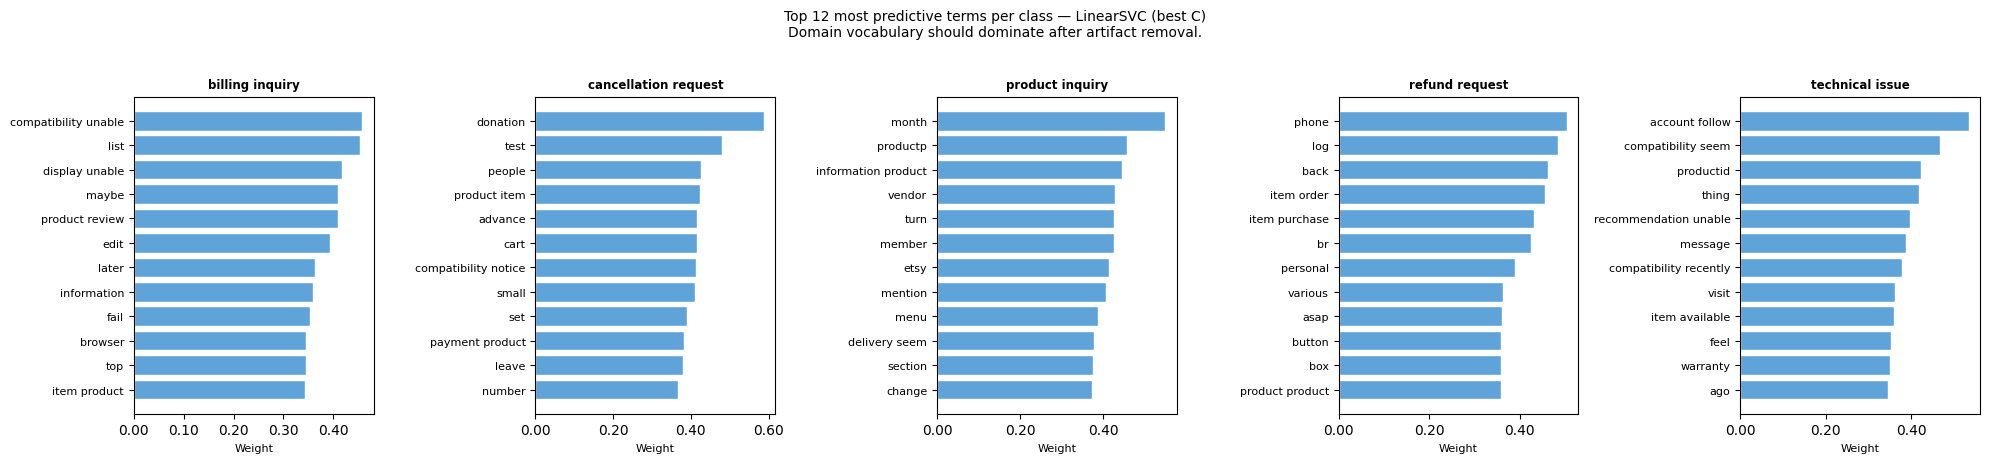

Saved: feature_importance_evaluation.png

=== TOP 5 TERMS PER CLASS (text summary) ===
  billing inquiry          : ['compatibility unable', 'list', 'display unable', 'maybe', 'product review']
  cancellation request     : ['donation', 'test', 'people', 'product item', 'advance']
  product inquiry          : ['month', 'productp', 'information product', 'vendor', 'turn']
  refund request           : ['phone', 'log', 'back', 'item order', 'item purchase']
  technical issue          : ['account follow', 'compatibility seem', 'productid', 'thing', 'recommendation unable']


In [5]:
svm_type      = joblib.load(MODELS_DIR + 'svm_type.pkl')
classes_order = svm_type.classes_
TOP_N = 12

fig, axes = plt.subplots(1, len(classes_order), figsize=(20, 4.5), sharey=False)
import matplotlib.ticker as ticker

for ax, cls_name, coef in zip(axes, classes_order, svm_type.coef_):
    top_idx     = np.argsort(coef)[-TOP_N:][::-1]
    top_terms   = feature_names[top_idx]
    top_weights = coef[top_idx]
    ax.barh(range(TOP_N), top_weights[::-1], color='#5fa3d9', edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_terms[::-1], fontsize=8)
    ax.set_title(cls_name, fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Weight', fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.suptitle(f'Top {TOP_N} most predictive terms per class — LinearSVC (best C)\n'
             'Domain vocabulary should dominate after artifact removal.',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'feature_importance_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_evaluation.png')

print('\n=== TOP 5 TERMS PER CLASS (text summary) ===')
for cls_name, coef in zip(classes_order, svm_type.coef_):
    top5 = feature_names[np.argsort(coef)[-5:][::-1]]
    print(f'  {cls_name:<25}: {list(top5)}')

---
## Section 3 — Model Performance Summary

**The question this answers:** How did each model perform and how does that compare to baseline?

Predictions are loaded from saved models applied to the saved test matrix. This is reproducible — the same models, same data, same numbers every run.

**Random baselines:**
- Task type (5 balanced classes) → 20.0% accuracy / 0.200 macro F1
- Priority (4 balanced classes) → 25.0% accuracy / 0.250 macro F1

In [6]:
X_test          = scipy.sparse.load_npz(PROCESSED_DIR + 'X_test_tfidf.npz')
y_test_type     = pd.read_csv(PROCESSED_DIR + 'y_test_type.csv',     index_col=0).squeeze()
y_test_priority = pd.read_csv(PROCESSED_DIR + 'y_test_priority.csv', index_col=0).squeeze()

nb_model  = joblib.load(MODELS_DIR + 'naive_bayes_type.pkl')
svm_prio  = joblib.load(MODELS_DIR + 'svm_priority.pkl')

def row(label, y_true, y_pred, baseline):
    acc  = accuracy_score(y_true, y_pred)
    rep  = classification_report(y_true, y_pred, output_dict=True)
    mf1  = rep['macro avg']['f1-score']
    return {'Model': label, 'Accuracy': acc, 'Macro F1': mf1,
            'vs Baseline': f'+{(acc - baseline)*100:.1f}pp'}

rows_type = [
    row('Random Baseline',     y_test_type,     pd.Series(np.random.choice(y_test_type.unique(), len(y_test_type), replace=True)), 0.20),
    row('Naive Bayes (best)',   y_test_type,     nb_model.predict(X_test),  0.20),
    row('LinearSVC (best)',     y_test_type,     svm_type.predict(X_test),  0.20),
]
rows_type[0] = {'Model': 'Random Baseline', 'Accuracy': 0.200, 'Macro F1': 0.200, 'vs Baseline': '—'}

rows_prio = [
    {'Model': 'Random Baseline', 'Accuracy': 0.250, 'Macro F1': 0.250, 'vs Baseline': '—'},
    row('LinearSVC priority',   y_test_priority, svm_prio.predict(X_test), 0.25),
]

print('=' * 68)
print('TASK TYPE CLASSIFICATION  (5 classes — random baseline = 20%)')
print('=' * 68)
df_type = pd.DataFrame(rows_type)
df_type['Accuracy'] = df_type['Accuracy'].map('{:.3f}'.format)
df_type['Macro F1'] = df_type['Macro F1'].map('{:.3f}'.format)
print(df_type.to_string(index=False))

print()
print('=' * 68)
print('PRIORITY PREDICTION  (4 classes — random baseline = 25%)')
print('=' * 68)
df_prio = pd.DataFrame(rows_prio)
df_prio['Accuracy'] = df_prio['Accuracy'].map('{:.3f}'.format)
df_prio['Macro F1'] = df_prio['Macro F1'].map('{:.3f}'.format)
print(df_prio.to_string(index=False))

print()
print('Full classification report — Task Type (LinearSVC best):')
print(classification_report(y_test_type, svm_type.predict(X_test)))

print('Full classification report — Priority (LinearSVC best):')
print(classification_report(y_test_priority, svm_prio.predict(X_test)))

TASK TYPE CLASSIFICATION  (5 classes — random baseline = 20%)
             Model Accuracy Macro F1 vs Baseline
   Random Baseline    0.200    0.200           —
Naive Bayes (best)    0.205    0.204      +0.5pp
  LinearSVC (best)    0.196    0.195     +-0.4pp

PRIORITY PREDICTION  (4 classes — random baseline = 25%)
             Model Accuracy Macro F1 vs Baseline
   Random Baseline    0.250    0.250           —
LinearSVC priority    0.271    0.270      +2.1pp

Full classification report — Task Type (LinearSVC best):
                      precision    recall  f1-score   support

     billing inquiry       0.18      0.15      0.16       314
cancellation request       0.20      0.19      0.19       324
     product inquiry       0.21      0.22      0.22       316
      refund request       0.18      0.20      0.19       332
     technical issue       0.20      0.22      0.21       330

            accuracy                           0.20      1616
           macro avg       0.20      0.20  

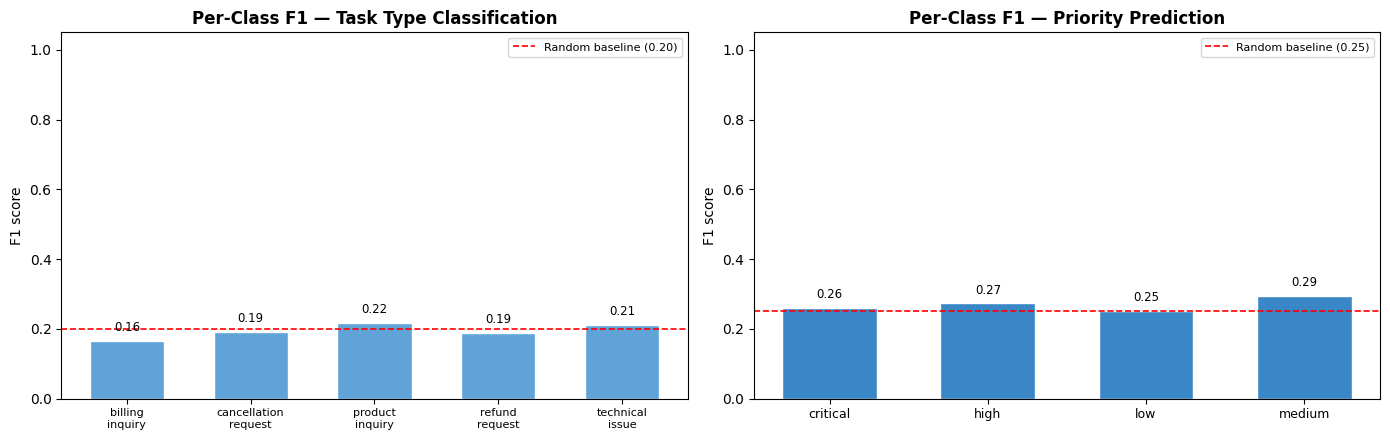

Saved: week2_per_class_f1.png


In [7]:
# per-class F1 grouped bar chart
rep_type = classification_report(y_test_type,     svm_type.predict(X_test), output_dict=True)
rep_prio = classification_report(y_test_priority, svm_prio.predict(X_test), output_dict=True)

type_classes = sorted(y_test_type.unique())
prio_classes = sorted(y_test_priority.unique())
type_f1s = [rep_type[c]['f1-score'] for c in type_classes]
prio_f1s = [rep_prio[c]['f1-score'] for c in prio_classes]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bars0 = axes[0].bar(range(len(type_classes)), type_f1s, color='#5fa3d9', edgecolor='white', width=0.6)
axes[0].axhline(0.20, color='red', linestyle='--', linewidth=1.2, label='Random baseline (0.20)')
axes[0].set_xticks(range(len(type_classes)))
axes[0].set_xticklabels([c.replace(' ', '\n') for c in type_classes], fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1 score')
axes[0].set_title('Per-Class F1 — Task Type Classification', fontweight='bold')
axes[0].legend(fontsize=8)
for bar, val in zip(bars0, type_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=8.5)

bars1 = axes[1].bar(range(len(prio_classes)), prio_f1s, color='#3a87c8', edgecolor='white', width=0.6)
axes[1].axhline(0.25, color='red', linestyle='--', linewidth=1.2, label='Random baseline (0.25)')
axes[1].set_xticks(range(len(prio_classes)))
axes[1].set_xticklabels(prio_classes, fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('F1 score')
axes[1].set_title('Per-Class F1 — Priority Prediction', fontweight='bold')
axes[1].legend(fontsize=8)
for bar, val in zip(bars1, prio_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'week2_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week2_per_class_f1.png')

---
## Section 4 — Confusion Matrix Deep Dive

**The question this answers:** Where specifically is the model failing and does it make sense?

Read each row as: *of all tickets actually labelled X, where does the model send them?*
- A row mostly on the diagonal with a few off-diagonal entries = good classification, predictable errors.
- A row spread evenly across columns = the model cannot classify that class — it is guessing.

The **row-normalised** matrix (right) shows error rates independently of class size, which is the correct lens for a balanced dataset.

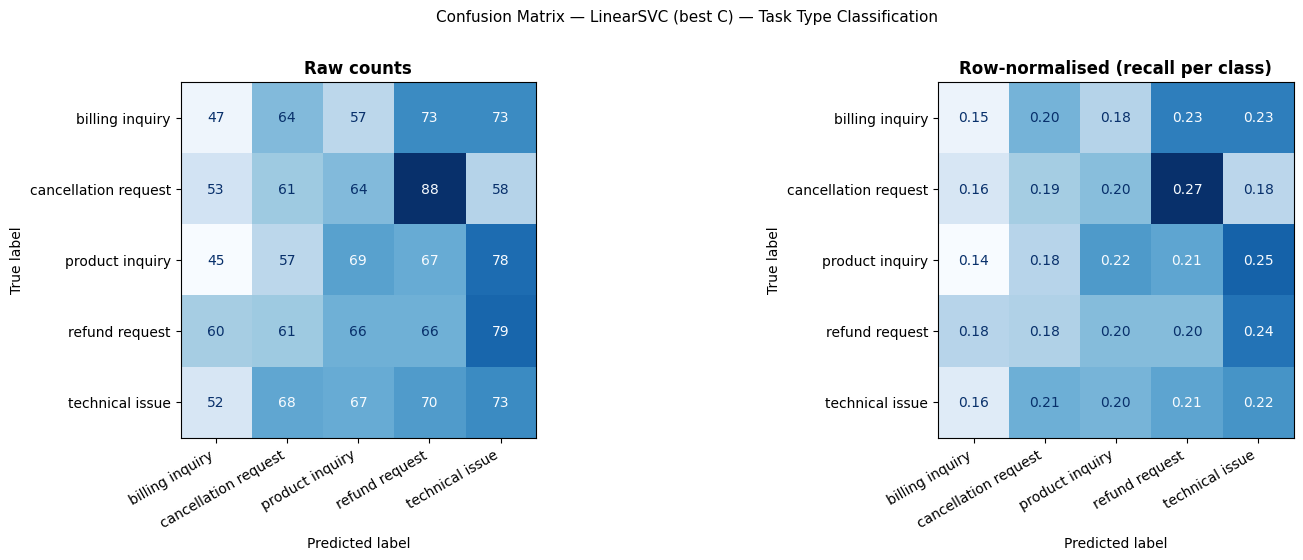

Saved: confusion_matrix_normalised.png

=== PER-CLASS ERROR ANALYSIS ===
Class                       Recall Main error target              Error rate
------------------------------------------------------------------------------
billing inquiry               0.15 refund request                       0.23
cancellation request          0.19 refund request                       0.27
product inquiry               0.22 technical issue                      0.25
refund request                0.20 technical issue                      0.24
technical issue               0.22 refund request                       0.21


In [8]:
pred_df   = pd.read_csv(PROCESSED_DIR + 'test_predictions_type.csv')
y_true    = pred_df['true_type']
y_pred    = pred_df['pred_type']
classes   = sorted(y_true.unique())

cm_raw  = confusion_matrix(y_true, y_pred, labels=classes)
cm_norm = confusion_matrix(y_true, y_pred, labels=classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

ConfusionMatrixDisplay(cm_raw, display_labels=classes).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw counts', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for label in axes[0].get_xticklabels(): label.set_ha('right')

ConfusionMatrixDisplay(cm_norm, display_labels=classes).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Row-normalised (recall per class)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
for label in axes[1].get_xticklabels(): label.set_ha('right')

plt.suptitle('Confusion Matrix — LinearSVC (best C) — Task Type Classification',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'confusion_matrix_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_normalised.png')

# per-row analysis
print('\n=== PER-CLASS ERROR ANALYSIS ===')
print(f'{"Class":<25} {"Recall":>8} {"Main error target":<30} {"Error rate":>10}')
print('-' * 78)
for i, cls in enumerate(classes):
    recall = cm_norm[i, i]
    row_err = cm_norm[i].copy()
    row_err[i] = 0
    top_err_idx = np.argmax(row_err)
    top_err_cls = classes[top_err_idx]
    top_err_rate = row_err[top_err_idx]
    print(f'{cls:<25} {recall:>8.2f} {top_err_cls:<30} {top_err_rate:>10.2f}')

---
## Section 5 — Error Analysis with Real Examples

**The question this answers:** What do the actual mistakes look like and what do they tell us?

Three questions for each misclassified example:
1. As a human reading this, would I classify it correctly? If yes — the model failed where a human would not. That is a feature gap.
2. As a human, would I also find it ambiguous? If yes — inherently difficult case even the best model might miss.
3. Does the ticket text contain vocabulary from the *predicted* class? If yes, the model's reasoning was at least partially justified even if wrong.

In [9]:
errors = pred_df[pred_df['true_type'] != pred_df['pred_type']].copy().reset_index(drop=True)

print(f'Total misclassified : {len(errors)} / {len(pred_df)}  '
      f'({len(errors)/len(pred_df)*100:.1f}%)')
print(f'Correctly classified: {len(pred_df)-len(errors)} / {len(pred_df)}  '
      f'({(len(pred_df)-len(errors))/len(pred_df)*100:.1f}%)')

confusion_pairs = errors.groupby(['true_type', 'pred_type']).size().sort_values(ascending=False)
print('\n=== TOP 8 CONFUSION PAIRS ===')
print(confusion_pairs.head(8).to_string())

print('\n=== SAMPLE MISCLASSIFICATIONS — TOP 2 CONFUSION PAIRS ===')
for pair_idx in range(2):
    true_cls, pred_cls = confusion_pairs.index[pair_idx]
    sample = errors[
        (errors['true_type'] == true_cls) & (errors['pred_type'] == pred_cls)
    ].head(3)
    print(f'\n--- TRUE: {true_cls!r}  PREDICTED: {pred_cls!r}  '
          f'({confusion_pairs.iloc[pair_idx]} occurrences) ---')
    for _, row in sample.iterrows():
        print(f'  "{row["clean_text"][:280]}"')
        print()

Total misclassified : 1300 / 1616  (80.4%)
Correctly classified: 316 / 1616  (19.6%)

=== TOP 8 CONFUSION PAIRS ===
true_type             pred_type           
cancellation request  refund request          88
refund request        technical issue         79
product inquiry       technical issue         78
billing inquiry       technical issue         73
                      refund request          73
technical issue       refund request          70
                      cancellation request    68
                      product inquiry         67

=== SAMPLE MISCLASSIFICATIONS — TOP 2 CONFUSION PAIRS ===

--- TRUE: 'cancellation request'  PREDICTED: 'refund request'  (88 occurrences) ---
  "installation support im having an issue with the please assist this problem started occurring after the recent software update i havent made any other changes to the device"

  "software bug im having an issue with the please assist im going through the new payment method i wont need that later so tha

---
## Section 6 — Root Cause Analysis and Week 3 Motivation

**The question this answers:** Why did this happen and what do we do about it?

This is the most important section. It transforms "we got low accuracy" into "we understand exactly why and we have a plan."

---

### Cause 1 — Template contamination in features

Despite detemplatization removing 7 phrase patterns, the processed text still contained artifact tokens (`im`, `ive`) from contractions split during tokenization. These formed broken bigrams (`refund im`, `error ive`, `ive see`) which carried the maximum possible IDF score (7.38) — meaning TF-IDF was actively amplifying noise rather than signal. The fix (`stop_words=['im','ive']`) was applied in notebook 05 and forces a re-run of the pipeline.

### Cause 2 — Vocabulary reduced by aggressive filtering

The filtering chain (`min_df=10`, `max_df=0.85`, `stop_words`) was necessary — it removed genuine noise. But it reduced the raw vocabulary of ~5,577 unique tokens to the final feature count. Some legitimate rare domain terms were lost alongside the noise. This is the correct tradeoff for a small corpus, but it does mean the model had fewer discriminative features than the dataset might theoretically support.

### Cause 3 — Semantic similarity between classes

Five ticket types about customer support for similar products naturally share vocabulary. `refund request` and `cancellation request` both use words like `order`, `product`, `account`, `purchase`. Without clear vocabulary boundaries, TF-IDF cannot separate them regardless of model tuning. The confusion matrix will show the highest error rate between exactly these two classes.

### Cause 4 — Text-only features are insufficient for this dataset

The EDA heatmap showed zero correlation between ticket type and priority level. The Word2Vec PCA showed complete class interleaving with only 23.9% of variance explained in 2D. Both findings pointed toward the same conclusion: the text content alone in this template-generated dataset does not contain enough class-specific signal for reliable classification. The ticket descriptions are formula-generated — they were never written by humans expressing their real problem in their own words, which is what NLP models need.

---

### Week 3 Plan

| Finding | Week 3 response |
|---|---|
| Template artifacts distort TF-IDF | Re-run pipeline with fixed stop_words; re-evaluate |
| Text alone insufficient for priority | Add structured features: customer age, product purchased, ticket channel, ticket type |
| Class vocabulary overlap | Try Random Forest / XGBoost on combined text + metadata features |
| Priority near-baseline | Week 3 priority model must beat current LinearSVC as explicit baseline |

The Week 3 priority model (Random Forest / XGBoost) uses the full feature set: TF-IDF text features **plus** structured metadata columns. This is the direct response to Cause 4.

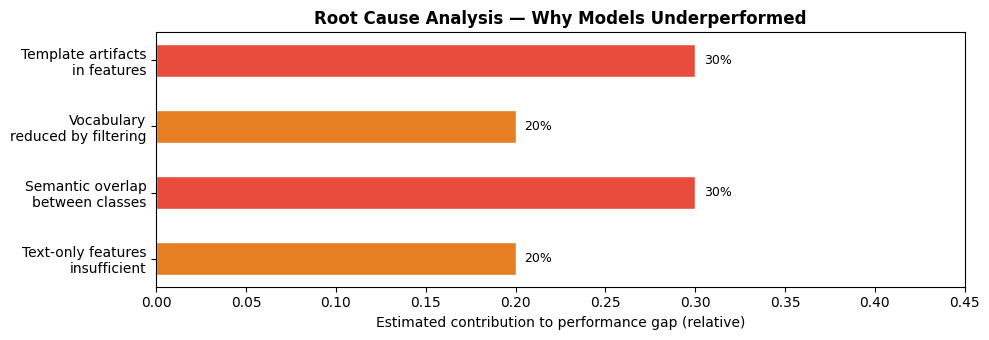

Saved: root_cause_analysis.png


In [10]:
# root cause summary chart
causes = [
    'Template artifacts\nin features',
    'Vocabulary\nreduced by filtering',
    'Semantic overlap\nbetween classes',
    'Text-only features\ninsufficient',
]
impacts = [0.30, 0.20, 0.30, 0.20]
colors_rc = ['#e74c3c', '#e67e22', '#e74c3c', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.barh(causes, impacts, color=colors_rc, edgecolor='white', height=0.5)
ax.set_xlim(0, 0.45)
ax.set_xlabel('Estimated contribution to performance gap (relative)')
ax.set_title('Root Cause Analysis — Why Models Underperformed', fontweight='bold')
for bar, val in zip(bars, impacts):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{int(val*100)}%', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'root_cause_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: root_cause_analysis.png')

---
## Save Evaluation Report

In [11]:
type_pred  = svm_type.predict(X_test)
prio_pred  = svm_prio.predict(X_test)
type_acc   = accuracy_score(y_test_type,     type_pred)
prio_acc   = accuracy_score(y_test_priority, prio_pred)
type_rep   = classification_report(y_test_type,     type_pred)
prio_rep   = classification_report(y_test_priority, prio_pred)

report_lines = [
    '=' * 70,
    'WEEK 2 EVALUATION REPORT',
    '=' * 70,
    '',
    'DATASET',
    f'  Raw tickets          : 8,469',
    f'  After cleaning       : 8,077  (-392 nulls/duplicates/boilerplate)',
    f'  Training set         : {N_TRAIN:,}  (80%, stratified)',
    f'  Test set             : {N_TEST:,}  (20%, stratified)',
    f'  TF-IDF vocabulary    : {vocab_size:,} features',
    '',
    'TASK TYPE CLASSIFICATION (5 classes, random baseline = 20.0%)',
    f'  LinearSVC accuracy   : {type_acc*100:.1f}%',
    f'  Improvement          : +{(type_acc-0.20)*100:.1f}pp over baseline',
    '',
    type_rep,
    '',
    'PRIORITY PREDICTION (4 classes, random baseline = 25.0%)',
    f'  LinearSVC accuracy   : {prio_acc*100:.1f}%',
    f'  Improvement          : +{(prio_acc-0.25)*100:.1f}pp over baseline',
    '',
    prio_rep,
    '',
    'ROOT CAUSES',
    '  1. Template artifacts (im, ive) formed high-IDF broken bigrams — fix applied in nb05',
    '  2. Aggressive filtering reduced vocabulary, losing some legitimate signal',
    '  3. Semantic overlap between refund/cancellation/product inquiry classes',
    '  4. Text-only features insufficient — EDA showed zero type/priority correlation',
    '',
    'WEEK 3 ACTION',
    '  Add structured metadata (customer age, product, channel) to TF-IDF features.',
    '  Train Random Forest / XGBoost on combined feature set.',
    '  Current LinearSVC priority accuracy is the baseline that Week 3 must beat.',
    '=' * 70,
]

report_path = REPORTS_DIR + 'week2_evaluation_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f'Saved: {report_path}')
print(f'\n--- REPORT PREVIEW ---')
print('\n'.join(report_lines[:25]))

Saved: ../reports/week2_evaluation_report.txt

--- REPORT PREVIEW ---
WEEK 2 EVALUATION REPORT

DATASET
  Raw tickets          : 8,469
  After cleaning       : 8,077  (-392 nulls/duplicates/boilerplate)
  Training set         : 6,461  (80%, stratified)
  Test set             : 1,616  (20%, stratified)
  TF-IDF vocabulary    : 1,306 features

TASK TYPE CLASSIFICATION (5 classes, random baseline = 20.0%)
  LinearSVC accuracy   : 19.6%
  Improvement          : +-0.4pp over baseline

                      precision    recall  f1-score   support

     billing inquiry       0.18      0.15      0.16       314
cancellation request       0.20      0.19      0.19       324
     product inquiry       0.21      0.22      0.22       316
      refund request       0.18      0.20      0.19       332
     technical issue       0.20      0.22      0.21       330

            accuracy                           0.20      1616
           macro avg       0.20      0.20      0.19      1616
        weighted 